tracking scenario


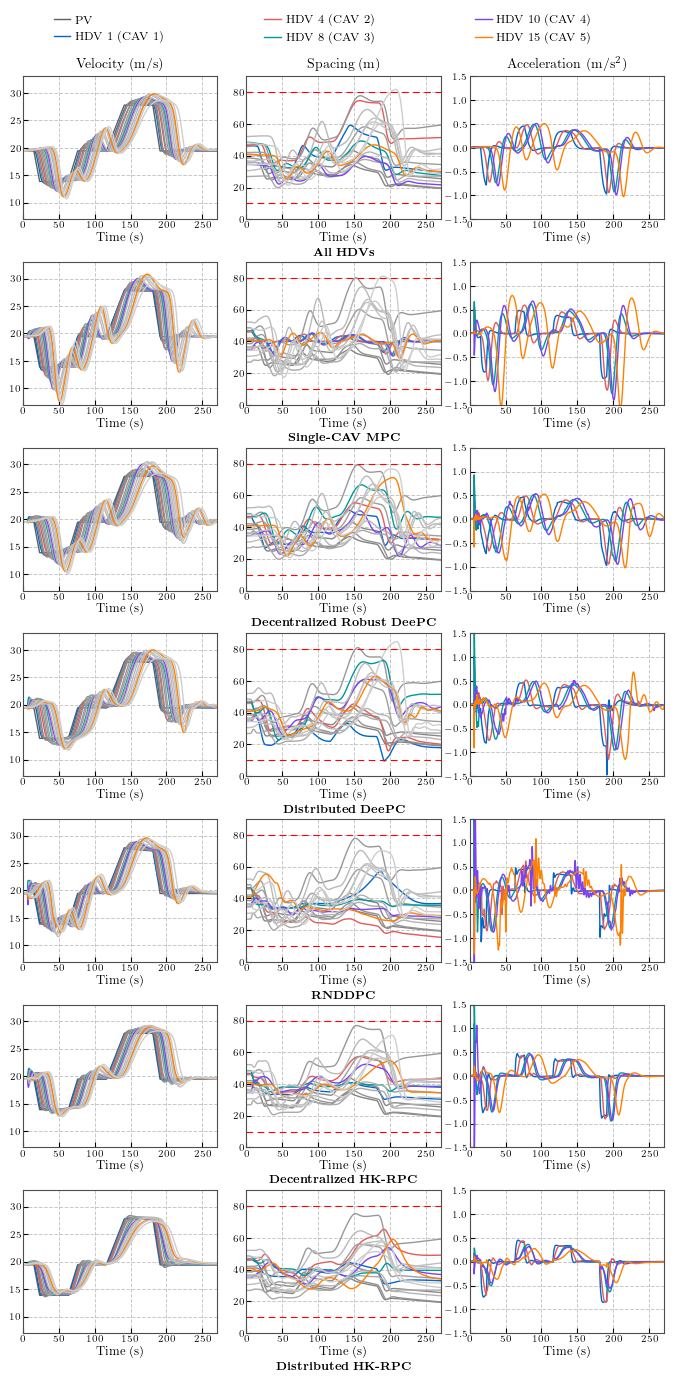

7x3 figures for paper/Time varying/tracking_comparison_7x3.pdf


In [1]:
import glob
import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt


def load_vehicle_data_to_S(data_dir):
    files = sorted(
        [f for f in os.listdir(data_dir) if re.match(r'veh_\d+\.csv', f)],
        key=lambda f: int(re.search(r'\d+', f).group())
    )
    if not files:
        raise FileNotFoundError(f"No veh_X.csv files found in {data_dir}")

    data_list = []
    for f in files:
        df = pd.read_csv(os.path.join(data_dir, f))
        data_list.append(df[['position', 'velocity', 'acceleration']].values)

    S = np.stack(data_list, axis=1)  # (time_steps, num_vehicles, 3)
    return S


def plot_tracking_comparison_7x3(Tstep, sub_numHDV, num_CAV=1):
    sim_subplatoon_num = len(sub_numHDV)

    plt.style.use('default')
    plt.rcParams['text.usetex'] = True
    plt.rcParams.update({'font.family': 'Times New Roman'})

    FS_METHOD = 8.5
    FS_TITLE = 10
    FS_LABEL = 9
    FS_TICK = 7
    FS_LEGEND = 8.5
    plt.rc('xtick', labelsize=FS_TICK, direction='in')
    plt.rc('ytick', labelsize=FS_TICK, direction='in')

    method_entries = [
        ('All HDVs', '202606_result/tracking/All_HDVs_20260722_114741/vehicle_data'),
        ('Single-CAV MPC', 'comparison/single_MPC/result/tracking/Decentralized_single_MPC_20260721_170711/vehicle_data'),
        ('Decentralized Robust DeePC', 'comparison/dDeeP_LCC_Shang2024/result/tracking/dDeeP_LCC_20260722_003050/vehicle_data'),
        ('Distributed DeePC', 'comparison/distributed_DeePC/result/tracking/Distributed_DeePC_20260721_193816/vehicle_data'),
        ('RNDDPC', 'comparison/RNDDPC_Li2026/result/tracking/RNDDPC_20260723_202915/vehicle_data'),
        ('Decentralized HK-RPC', '202606_result/tracking/Decentralized_MPC_20260720_151950/vehicle_data'),
        ('Distributed HK-RPC', '202606_result/tracking/Distributed_MPC_20260720_153122/vehicle_data'),
    ]

    data = {}
    resolved_paths = {}
    for method_name, data_path in method_entries:
        resolved_paths[method_name] = data_path
        data[method_name] = load_vehicle_data_to_S(data_path) if data_path is not None else None

    first_S = next(S for S in data.values() if S is not None)
    max_time = max((S.shape[0] - 1) * Tstep for S in data.values() if S is not None)

    my_colors_cav = ['#0066CC', '#E35A58', '#009999', '#7A42F4', '#FF8000']
    my_colors_veh = plt.cm.Greys(np.linspace(0.6, 0.3, first_S.shape[1]))
    my_colors_PV = '#5F5F5E'

    #  3x5 cell 
    fig, axs = plt.subplots(7, 3, figsize=(7.2, 14.2))

    vel_lim = [7, 33]
    spa_lim = [0, 90]
    acc_lim = [-1.5, 1.5]
    column_titles = [
        r'Velocity $(\mathrm{m/s})$',
        r'Spacing $(\mathrm{m})$',
        r'Acceleration $(\mathrm{m/s^2})$',
    ]
    cav_legend_labels = [
        'HDV 1 (CAV 1)',
        'HDV 4 (CAV 2)',
        'HDV 8 (CAV 3)',
        'HDV 10 (CAV 4)',
        'HDV 15 (CAV 5)',
    ]

    all_lines = []
    all_labels = []

    def style_axis(ax, row, col, ylim):
        ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
        ax.set_ylim(ylim)
        ax.set_xlim([0, max_time])
        ax.tick_params(axis='both', which='both', labelsize=FS_TICK, pad=1.5)
        ax.tick_params(axis='x', pad=1.5)
        ax.set_xlabel(r'Time $(\mathrm{s})$', fontproperties='Times New Roman', fontsize=FS_LABEL, labelpad=1)
        for spine in ax.spines.values():
            spine.set_color('#4D4D4D')
            spine.set_linewidth(0.8)

    for row, (method_name, _) in enumerate(method_entries):
        S = data[method_name]

        for col, title in enumerate(column_titles):
            if row == 0:
                axs[row, col].set_title(title, fontproperties='Times New Roman', fontsize=FS_TITLE)

        if S is None:
            for col, ylim in enumerate((vel_lim, spa_lim, acc_lim)):
                style_axis(axs[row, col], row, col, ylim)
                axs[row, col].text(
                    0.5, 0.5, 'To be added',
                    transform=axs[row, col].transAxes,
                    ha='center', va='center',
                    fontsize=FS_METHOD,
                    color='#777777',
                )
            continue

        time_list = np.arange(S.shape[0]) * Tstep

        # ==================== Velocity ====================
        line, = axs[row, 0].plot(time_list, S[:, 0, 1], color=my_colors_PV, linewidth=1)
        if row == 0:
            all_lines.append(line)
            all_labels.append('PV')

        veh_idx = 1
        for subplatoon_idx in range(sim_subplatoon_num):
            if veh_idx < S.shape[1]:
                line, = axs[row, 0].plot(
                    time_list, S[:, veh_idx, 1],
                    color=my_colors_cav[subplatoon_idx], linewidth=1
                )
                if row == 0:
                    all_lines.append(line)
                    all_labels.append(cav_legend_labels[subplatoon_idx])
                veh_idx += 1

            for _ in range(sub_numHDV[subplatoon_idx]):
                if veh_idx < S.shape[1]:
                    axs[row, 0].plot(
                        time_list, S[:, veh_idx, 1],
                        color=my_colors_veh[min(veh_idx, len(my_colors_veh) - 1)], linewidth=1
                    )
                    veh_idx += 1

        style_axis(axs[row, 0], row, 0, vel_lim)

        # ==================== Spacing ====================
        veh_idx = 1
        for subplatoon_idx in range(sim_subplatoon_num):
            if veh_idx < S.shape[1]:
                spacing = S[:, veh_idx - 1, 0] - S[:, veh_idx, 0]
                axs[row, 1].plot(time_list, spacing, color=my_colors_cav[subplatoon_idx], linewidth=1)
                veh_idx += 1

            for _ in range(sub_numHDV[subplatoon_idx]):
                if veh_idx < S.shape[1]:
                    spacing = S[:, veh_idx - 1, 0] - S[:, veh_idx, 0]
                    axs[row, 1].plot(
                        time_list, spacing,
                        color=my_colors_veh[min(veh_idx, len(my_colors_veh) - 1)], linewidth=1
                    )
                    veh_idx += 1

        axs[row, 1].axhline(10, color='red', linewidth=0.8, linestyle=(0, (6, 4)))
        axs[row, 1].axhline(80, color='red', linewidth=0.8, linestyle=(0, (6, 4)))
        style_axis(axs[row, 1], row, 1, spa_lim)

        # ==================== Acceleration ====================
        veh_idx = 1
        for subplatoon_idx in range(sim_subplatoon_num):
            if veh_idx < S.shape[1]:
                axs[row, 2].plot(
                    time_list, S[:, veh_idx, 2],
                    color=my_colors_cav[subplatoon_idx], linewidth=1
                )
            veh_idx += 1 + sub_numHDV[subplatoon_idx]

        style_axis(axs[row, 2], row, 2, acc_lim)

    fig.legend(
        all_lines, all_labels,
        loc='upper center',
        ncol=3,
        prop={'family': 'Times New Roman', 'size': FS_LEGEND},
        frameon=False,
        bbox_to_anchor=(0.12, 0.932, 0.76, 0.055),
        mode='expand',
        borderaxespad=0.0,
        handlelength=1.4,
        handletextpad=0.4,
        columnspacing=0.8,
    )

    plt.tight_layout(rect=[0.045, 0.035, 0.995, 0.945])
    plt.subplots_adjust(wspace=0.15, hspace=0.3, top=0.94, bottom=0.055)

    for row, (method_name, _) in enumerate(method_entries):
        row_left = axs[row, 0].get_position().x0
        row_right = axs[row, 2].get_position().x1
        label_y = axs[row, 1].get_position().y0 - 0.02
        fig.text(
            0.5 * (row_left + row_right),
            label_y,
            r'\textbf{' + method_name.replace('_', r'\_') + '}',
            ha='center',
            va='top',
            fontsize=FS_METHOD,
            fontproperties='Times New Roman',
        )

    os.makedirs('figures for paper/Time varying', exist_ok=True)
    plt.savefig('figures for paper/Time varying/tracking_comparison_7x3.pdf', bbox_inches='tight')
    plt.show()

    print('7x3 figures for paper/Time varying/tracking_comparison_7x3.pdf')


if __name__ == '__main__':
    plot_tracking_comparison_7x3(Tstep=0.12, sub_numHDV=(2,3,1,4,2), num_CAV=1)


cut in scenario

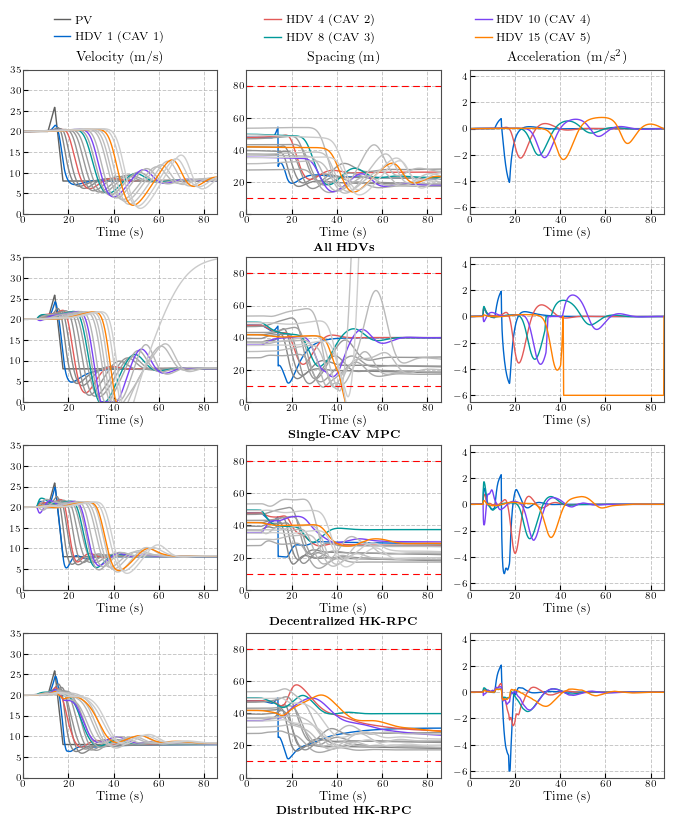

4x3 figures for paper/Time varying/cutin_comparison_4x3.pdf


In [2]:
import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.patches as patches

def load_vehicle_data_to_S(data_dir):
    files = sorted(
        [f for f in os.listdir(data_dir) if re.match(r'veh_\d+\.csv', f)],
        key=lambda f: int(re.search(r'\d+', f).group())
    )
    if not files:
        raise FileNotFoundError(f"No veh_X.csv files found in {data_dir}")

    data_list = []
    for f in files:
        df = pd.read_csv(os.path.join(data_dir, f))
        data_list.append(df[['position', 'velocity', 'acceleration']].values)

    S = np.stack(data_list, axis=1)
    return S


def plot_cutin_comparison_4x3(Tstep=0.12, sub_numHDV=(2, 3, 1, 4, 2), num_CAV=1):
    sim_subplatoon_num = len(sub_numHDV)

    plt.style.use('default')
    plt.rcParams['text.usetex'] = True
    plt.rcParams.update({'font.family': 'Times New Roman'})

    FS_METHOD = 8.5
    FS_TITLE = 10
    FS_LABEL = 9
    FS_TICK = 7
    FS_LEGEND = 8.5
    plt.rc('xtick', labelsize=FS_TICK, direction='in')
    plt.rc('ytick', labelsize=FS_TICK, direction='in')

    method_entries = [
        ('All HDVs', '202606_result/cutin/All_HDVs_20260722_114254/vehicle_data'),
        ('Single-CAV MPC', 'comparison/single_MPC/result/cutin/Decentralized_single_MPC_20260721_173021/vehicle_data'),
        ('Decentralized HK-RPC', '202606_result/cutin/Decentralized_MPC_20260721_173457/vehicle_data'),
        ('Distributed HK-RPC', '202606_result/cutin/Distributed_MPC_20260720_192837/vehicle_data'),
    ]

    data = {}
    for method_name, data_path in method_entries:
        data[method_name] = load_vehicle_data_to_S(data_path)

    first_S = next(S for S in data.values() if S is not None)
    max_time = max((S.shape[0] - 1) * Tstep for S in data.values() if S is not None)

    my_colors_cav = ['#0066CC', '#E35A58', '#009999', '#7A42F4', '#FF8000']
    my_colors_veh = plt.cm.Greys(np.linspace(0.6, 0.3, first_S.shape[1]))
    my_colors_PV = '#5F5F5E'

    fig, axs = plt.subplots(4, 3, figsize=(7.2, 8))

    vel_lim = [0, 35]
    spa_lim = [0, 90]
    acc_lim = [-6.5, 4.5]
    column_titles = [
        r'Velocity $(\mathrm{m/s})$',
        r'Spacing $(\mathrm{m})$',
        r'Acceleration $(\mathrm{m/s^2})$',
    ]
    cav_legend_labels = [
        'HDV 1 (CAV 1)',
        'HDV 4 (CAV 2)',
        'HDV 8 (CAV 3)',
        'HDV 10 (CAV 4)',
        'HDV 15 (CAV 5)',
    ]

    all_lines = []
    all_labels = []

    def style_axis(ax, ylim):
        ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
        ax.set_ylim(ylim)
        ax.set_xlim([0, max_time])
        ax.tick_params(axis='both', which='both', labelsize=FS_TICK, pad=1.5)
        ax.set_xlabel(r'Time $(\mathrm{s})$', fontproperties='Times New Roman', fontsize=FS_LABEL, labelpad=1)
        for spine in ax.spines.values():
            spine.set_color('#4D4D4D')
            spine.set_linewidth(0.8)

    for row, (method_name, _) in enumerate(method_entries):
        S = data[method_name]
        time_list = np.arange(S.shape[0]) * Tstep

        for col, title in enumerate(column_titles):
            if row == 0:
                axs[row, col].set_title(title, fontproperties='Times New Roman', fontsize=FS_TITLE)

        line, = axs[row, 0].plot(time_list, S[:, 0, 1], color=my_colors_PV, linewidth=1)
        if row == 0:
            all_lines.append(line)
            all_labels.append('PV')

        veh_idx = 1
        for subplatoon_idx in range(sim_subplatoon_num):
            if veh_idx < S.shape[1]:
                line, = axs[row, 0].plot(
                    time_list, S[:, veh_idx, 1],
                    color=my_colors_cav[subplatoon_idx], linewidth=1
                )
                if row == 0:
                    all_lines.append(line)
                    all_labels.append(cav_legend_labels[subplatoon_idx])
                veh_idx += 1

            for _ in range(sub_numHDV[subplatoon_idx]):
                if veh_idx < S.shape[1]:
                    axs[row, 0].plot(
                        time_list, S[:, veh_idx, 1],
                        color=my_colors_veh[min(veh_idx, len(my_colors_veh) - 1)], linewidth=1
                    )
                    veh_idx += 1

        style_axis(axs[row, 0], vel_lim)

        veh_idx = 1
        for subplatoon_idx in range(sim_subplatoon_num):
            if veh_idx < S.shape[1]:
                spacing = S[:, veh_idx - 1, 0] - S[:, veh_idx, 0]
                axs[row, 1].plot(time_list, spacing, color=my_colors_cav[subplatoon_idx], linewidth=1)
                veh_idx += 1

            for _ in range(sub_numHDV[subplatoon_idx]):
                if veh_idx < S.shape[1]:
                    spacing = S[:, veh_idx - 1, 0] - S[:, veh_idx, 0]
                    axs[row, 1].plot(
                        time_list, spacing,
                        color=my_colors_veh[min(veh_idx, len(my_colors_veh) - 1)], linewidth=1
                    )
                    veh_idx += 1

        axs[row, 1].axhline(10, color='red', linewidth=0.8, linestyle=(0, (6, 4)))
        axs[row, 1].axhline(80, color='red', linewidth=0.8, linestyle=(0, (6, 4)))
        style_axis(axs[row, 1], spa_lim)

        veh_idx = 1
        for subplatoon_idx in range(sim_subplatoon_num):
            if veh_idx < S.shape[1]:
                axs[row, 2].plot(
                    time_list, S[:, veh_idx, 2],
                    color=my_colors_cav[subplatoon_idx], linewidth=1
                )
            veh_idx += 1 + sub_numHDV[subplatoon_idx]

        style_axis(axs[row, 2], acc_lim)

    fig.legend(
        all_lines, all_labels,
        loc='upper center',
        ncol=3,
        prop={'family': 'Times New Roman', 'size': FS_LEGEND},
        frameon=False,
        bbox_to_anchor=(0.12, 0.96, 0.76, 0.055),
        mode='expand',
        borderaxespad=0.0,
        handlelength=1.4,
        handletextpad=0.4,
        columnspacing=0.8,
    )

    plt.tight_layout(rect=[0.045, 0.035, 0.995, 0.945])
    plt.subplots_adjust(wspace=0.15, hspace=0.3, top=0.94, bottom=0.055)

    for row, (method_name, _) in enumerate(method_entries):
        row_left = axs[row, 0].get_position().x0
        row_right = axs[row, 2].get_position().x1
        label_y = axs[row, 1].get_position().y0 - 0.035
        fig.text(
            0.5 * (row_left + row_right),
            label_y,
            r'\textbf{' + method_name.replace('_', r'\_') + '}',
            ha='center',
            va='top',
            fontsize=FS_METHOD,
            fontproperties='Times New Roman',
        )

    os.makedirs('figures for paper/Time varying', exist_ok=True)
    plt.savefig('figures for paper/Time varying/cutin_comparison_4x3.pdf', bbox_inches='tight')
    plt.show()

    print('4x3 figures for paper/Time varying/cutin_comparison_4x3.pdf')


if __name__ == '__main__':
    plot_cutin_comparison_4x3(Tstep=0.12, sub_numHDV=(2, 3, 1, 4, 2), num_CAV=1)

braking scenario


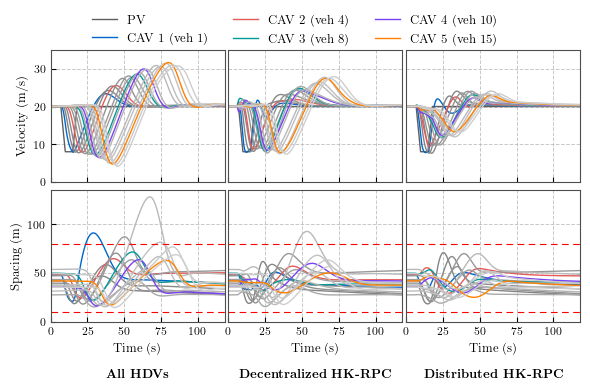

figures for paper/Time varying/braking_comparison.pdf


In [ ]:
import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.patches as patches


def load_vehicle_data_to_S(data_dir):
    files = sorted(
        [f for f in os.listdir(data_dir) if re.match(r'veh_\d+\.csv', f)],
        key=lambda f: int(re.search(r'\d+', f).group())
    )
    if not files:
        raise FileNotFoundError(f"No veh_X.csv files found in {data_dir}")

    data_list = []
    for f in files:
        df = pd.read_csv(os.path.join(data_dir, f))
        data_list.append(df[['position', 'velocity', 'acceleration']].values)

    S = np.stack(data_list, axis=1)
    return S


def plot_braking_comparison_2x3_original(Tstep=0.12, sub_numHDV=(2, 3, 1, 4, 2), num_CAV=1):
    sim_subplatoon_num = len(sub_numHDV)

    plt.style.use('default')
    plt.rcParams['text.usetex'] = True
    plt.rcParams.update({'font.family': 'Times New Roman'})
    plt.rc('xtick', labelsize=8, direction='in')
    plt.rc('ytick', labelsize=8, direction='in')

    FS_METHOD = 9
    FS_YLABEL = 9
    FS_LEGEND = 9

    methods = {
        'All HDVs': '202606_result/braking/All_HDVs_20260722_115315/vehicle_data',
        'Decentralized HK-RPC': '202606_result/braking/Decentralized_MPC_20260721_172722/vehicle_data',
        'Distributed HK-RPC': '202606_result/braking/Distributed_MPC_20260720_182039/vehicle_data',
    }

    data = {}
    for method_name, data_path in methods.items():
        data[method_name] = load_vehicle_data_to_S(data_path)

    my_colors_cav = ['#0066CC', '#E35A58', '#009999', '#7A42F4', '#FF8000']
    first_S = data[list(methods.keys())[0]]
    my_colors_veh = plt.cm.Greys(np.linspace(0.6, 0.3, first_S.shape[1]))
    my_colors_PV = '#5F5F5E'

    fig, axs = plt.subplots(2, 3, figsize=(6, 4))

    vel_lim = [0, 35]
    spa_lim = [0, 135]

    method_list = list(methods.keys())

    all_lines = []
    all_labels = []

    # ==================== Velocity ====================
    for col, method_name in enumerate(method_list):
        S = data[method_name]
        time_list = np.arange(S.shape[0]) * Tstep

        line, = axs[0, col].plot(time_list, S[:, 0, 1], color=my_colors_PV, linewidth=1)
        if col == 0:
            all_lines.append(line)
            all_labels.append('PV')

        veh_idx = 1
        for subplatoon_idx in range(sim_subplatoon_num):
            if veh_idx < S.shape[1]:
                line, = axs[0, col].plot(
                    time_list, S[:, veh_idx, 1],
                    color=my_colors_cav[subplatoon_idx], linewidth=1
                )
                if col == 0:
                    all_lines.append(line)
                    all_labels.append(f'CAV {subplatoon_idx + 1} (veh {veh_idx})')
                veh_idx += 1

            for _ in range(sub_numHDV[subplatoon_idx]):
                if veh_idx < S.shape[1]:
                    axs[0, col].plot(
                        time_list, S[:, veh_idx, 1],
                        color=my_colors_veh[min(veh_idx, len(my_colors_veh) - 1)], linewidth=1
                    )
                    veh_idx += 1

        axs[0, col].grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
        axs[0, col].set_ylim(vel_lim)
        axs[0, col].set_xlim([0, time_list[-1]])

        if col == 0:
            axs[0, col].set_ylabel(r'Velocity $(\mathrm{m/s})$', fontproperties="Times New Roman", fontsize=FS_YLABEL)
        else:
            axs[0, col].tick_params(axis='y', which='both', left=False, labelleft=False)

        axs[0, col].tick_params(labelbottom=False)

        for spine in axs[0, col].spines.values():
            spine.set_color('#4D4D4D')
            spine.set_linewidth(0.8)

    # ==================== Spacing ====================
    for col, method_name in enumerate(method_list):
        S = data[method_name]
        time_list = np.arange(S.shape[0]) * Tstep

        veh_idx = 1
        for subplatoon_idx in range(sim_subplatoon_num):
            if veh_idx < S.shape[1]:
                spacing = S[:, veh_idx - 1, 0] - S[:, veh_idx, 0]
                axs[1, col].plot(
                    time_list, spacing,
                    color=my_colors_cav[subplatoon_idx], linewidth=1
                )
                veh_idx += 1

            for _ in range(sub_numHDV[subplatoon_idx]):
                if veh_idx < S.shape[1]:
                    spacing = S[:, veh_idx - 1, 0] - S[:, veh_idx, 0]
                    axs[1, col].plot(
                        time_list, spacing,
                        color=my_colors_veh[min(veh_idx, len(my_colors_veh) - 1)], linewidth=1
                    )
                    veh_idx += 1

        axs[1, col].axhline(10, color='red', linewidth=0.8, linestyle=(0, (6, 4)))
        axs[1, col].axhline(80, color='red', linewidth=0.8, linestyle=(0, (6, 4)))

        axs[1, col].grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
        axs[1, col].set_ylim(spa_lim)
        axs[1, col].set_xlim([0, time_list[-1]])

        method_name_safe = method_name.replace('_', r'\_')
        axs[1, col].set_xlabel(
            r'Time $(\mathrm{s})$' + '\n\n' + r'\textbf{' + method_name_safe + '}',
            fontproperties="Times New Roman",
            fontsize=FS_METHOD
        )

        if col == 0:
            axs[1, col].set_ylabel(r'Spacing $(\mathrm{m})$', fontproperties="Times New Roman", fontsize=FS_YLABEL)
        else:
            axs[1, col].tick_params(axis='y', which='both', left=False, labelleft=False)

        for spine in axs[1, col].spines.values():
            spine.set_color('#4D4D4D')
            spine.set_linewidth(0.8)

    fig.legend(
        all_lines, all_labels,
        loc='upper center',
        ncol=3,
        prop={'family': 'Times New Roman', 'size': FS_LEGEND},
        frameon=False,
        bbox_to_anchor=(0.5, 0.98)
    )

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.subplots_adjust(wspace=0.02, hspace=0.06)

    os.makedirs('figures for paper/Time varying', exist_ok=True)
    plt.savefig('figures for paper/Time varying/braking_comparison.pdf', bbox_inches='tight')
    plt.show()

    print('figures for paper/Time varying/braking_comparison.pdf')


if __name__ == '__main__':
    plot_braking_comparison_2x3_original(Tstep=0.12, sub_numHDV=(2, 3, 1, 4, 2), num_CAV=1)


scaling factor alpha evolution

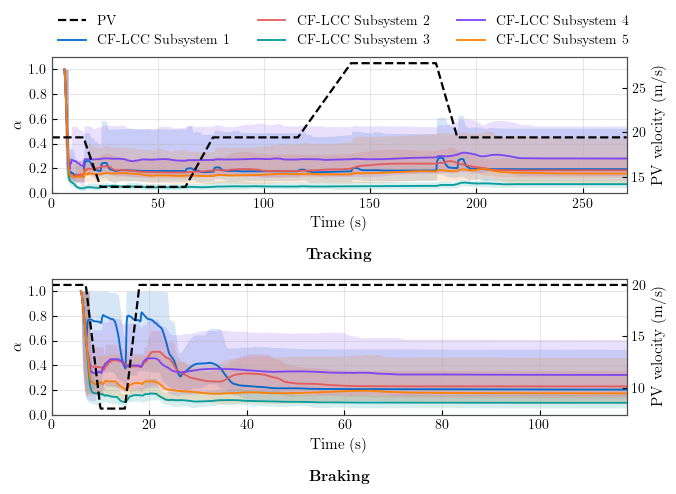

In [4]:
import glob
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

methods = {
    'Tracking': '202606_result/tracking/Distributed_MPC_20260720_153122/disturbance_set/alpha.csv',
    'Braking': '202606_result/braking/Distributed_MPC_20260720_182039/disturbance_set/alpha.csv',
}


my_colors_cav = [
    '#0066CC',  
    '#E35A58',  
    '#009999',  
    '#7A42F4',  
    '#FF8000'   
]

Tstep = 0.12
Npst = 50


def resolve_disturbance_dir(path):
    """Return the disturbance_set directory, with a fallback for timestamped runs."""
    candidate = os.path.dirname(path) if os.path.basename(path) == 'alpha.csv' else path
    if os.path.isdir(candidate):
        return candidate

    method_dir = os.path.dirname(candidate)
    scenario_dir = os.path.dirname(method_dir)
    method_prefix = os.path.basename(method_dir)
    matches = sorted(glob.glob(os.path.join(scenario_dir, f'{method_prefix}_*', 'disturbance_set')))
    if matches:
        return matches[-1]

    raise FileNotFoundError(f'Cannot find disturbance_set directory for: {path}')


plt.style.use('default')
plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
plt.rc('xtick', direction='in')
plt.rc('ytick', direction='in')

fig, axs = plt.subplots(2, 1, figsize=(7, 5), sharex=False)

global_handles, global_labels = [], []
legend_built = False

for row, (method_name, alpha_path) in enumerate(methods.items()):
    ax1 = axs[row]

    disturbance_dir = resolve_disturbance_dir(alpha_path)
    alpha_mean_data = pd.read_csv(os.path.join(disturbance_dir, 'alpha.csv'), header=None).to_numpy(dtype=float)
    sim_subplatoon_num, alpha_steps = alpha_mean_data.shape

    time_axis_alpha = np.arange(Npst, Npst + alpha_steps) * Tstep
    time_axis_pv = np.arange(0, Npst + alpha_steps) * Tstep

    base_dir = os.path.dirname(disturbance_dir)
    veh0_path = os.path.join(base_dir, 'vehicle_data', 'veh_0.csv')
    veh0_data = pd.read_csv(veh0_path)
    vel_pv = veh0_data['velocity'].values[:Npst + alpha_steps]

    # ---- alpha: line = mean over prediction horizon, band = min/max over 15 horizon steps ----
    alpha_lines = []
    for i in range(sim_subplatoon_num):
        color = my_colors_cav[i % len(my_colors_cav)]
        per_step_path = os.path.join(disturbance_dir, f'subplatoon_{i}_alpha_per_step.csv')

        if os.path.exists(per_step_path):
            alpha_per_step = pd.read_csv(per_step_path, header=None).to_numpy(dtype=float)
            alpha_line = alpha_per_step.mean(axis=0)
            alpha_lower = alpha_per_step.min(axis=0)
            alpha_upper = alpha_per_step.max(axis=0)
        else:
            alpha_line = alpha_mean_data[i, :]
            alpha_lower = alpha_line
            alpha_upper = alpha_line

        ax1.fill_between(
            time_axis_alpha,
            alpha_lower,
            alpha_upper,
            color=color,
            alpha=0.16,
            linewidth=0,
        )
        line_i, = ax1.plot(
            time_axis_alpha,
            alpha_line,
            linewidth=1.35,
            alpha=0.95,
            color=color,
            label=fr'CF-LCC Subsystem {i + 1}',
        )
        alpha_lines.append(line_i)

    ax1.set_ylabel(r'$\alpha$')
    ax1.set_ylim(0, 1.1)
    ax1.set_yticks(np.linspace(0, 1, 6))
    ax1.grid(True, alpha=0.3)
    ax1.yaxis.set_ticks_position('left')
    ax1.yaxis.set_label_position('left')
    ax1.tick_params(axis='y', which='both', labelleft=True, labelright=False)

    # ---- twin axis ----
    ax2 = ax1.twinx()
    pv_line, = ax2.plot(time_axis_pv, vel_pv, 'k--', linewidth=1.6, label='PV velocity')
    ax2.set_ylabel(r'PV velocity $(\mathrm{m/s})$')
    ax2.yaxis.set_ticks_position('right')
    ax2.yaxis.set_label_position('right')
    ax2.tick_params(axis='y', which='both', labelright=True, labelleft=False)

    # ---- Time ----
    method_name_safe = method_name.replace('_', r'\_')
    ax1.set_xlabel(
        r'Time $(\mathrm{s})$' + '\n\n' + r'\textbf{' + method_name_safe + '}',
        fontsize=11
    )

    ax1.set_xlim([time_axis_alpha[0], time_axis_alpha[-1]])
    ax2.set_xlim([time_axis_pv[0], time_axis_pv[-1]])

    # ---- ----
    for spine in ax1.spines.values():
        spine.set_color('#4D4D4D')
        spine.set_linewidth(0.8)

    for spine in ax2.spines.values():
        spine.set_color('#4D4D4D')
        spine.set_linewidth(0.8)

    # ---- legend only once ----
    if (row == 0) and (not legend_built):
        global_handles.append(pv_line)
        global_labels.append('PV')
        for i, h in enumerate(alpha_lines):
            global_handles.append(h)
            global_labels.append(f'CF-LCC Subsystem {i + 1}')
        legend_built = True

# ---- global legend ----
fig.legend(
    global_handles, global_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.995),
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

os.makedirs('figures for paper/Time varying', exist_ok=True)
plt.savefig('figures for paper/Time varying/alpha.pdf', bbox_inches='tight')
plt.show()


Sensitivity analysis of history horizon $N_{\mathrm{pst}}$: RMSE

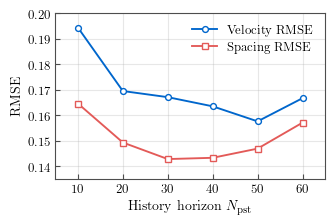

In [ ]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

npst_sensitivity = pd.DataFrame({
    'Npst': [10, 20, 30, 40, 50, 60],
    'Velocity RMSE': [0.1944, 0.1695, 0.1671, 0.1635, 0.1576, 0.1667],
    'Spacing RMSE': [0.1646, 0.1493, 0.1428, 0.1433, 0.1469, 0.1571],
})

plt.style.use('default')
plt.rcParams['text.usetex'] = True
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 10,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
plt.rc('xtick', direction='in')
plt.rc('ytick', direction='in')

my_colors_cav = ['#0066CC', '#E35A58', '#009999', '#7A42F4', '#FF8000']

fig, ax = plt.subplots(1, 1, figsize=(3.45, 2.35))

line_velocity, = ax.plot(
    npst_sensitivity['Npst'],
    npst_sensitivity['Velocity RMSE'],
    color=my_colors_cav[0],
    marker='o',
    markersize=4.2,
    markerfacecolor='white',
    markeredgewidth=1.0,
    linewidth=1.35,
    label='Velocity RMSE',
)
line_spacing, = ax.plot(
    npst_sensitivity['Npst'],
    npst_sensitivity['Spacing RMSE'],
    color=my_colors_cav[1],
    marker='s',
    markersize=4.0,
    markerfacecolor='white',
    markeredgewidth=1.0,
    linewidth=1.35,
    label='Spacing RMSE',
)

ax.set_xlabel(r'History horizon $N_{\mathrm{pst}}$')
ax.set_ylabel('RMSE')
ax.set_xlim(5, 65)
ax.set_xticks(npst_sensitivity['Npst'])
ax.set_ylim(0.135, 0.200)
ax.set_yticks(np.arange(0.14, 0.201, 0.01))
ax.grid(True, alpha=0.3)
ax.legend(
    handles=[line_velocity, line_spacing],
    loc='upper right',
    frameon=False,
    handlelength=2.0,
)

for spine in ax.spines.values():
    spine.set_color('#4D4D4D')
    spine.set_linewidth(0.8)

ax.tick_params(axis='both', which='both', color='#4D4D4D')

plt.tight_layout()

os.makedirs('figures for paper/Time varying', exist_ok=True)
plt.savefig('figures for paper/Time varying/history_horizon_rmse.pdf', bbox_inches='tight')
plt.show()


tracking simulation with delayed measurement

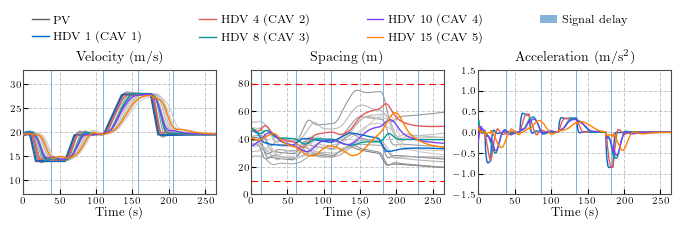

Result dir: 202606_result/tracking/Distributed_MPC_delayed
Delay windows: [(120, 124), (320, 324), (520, 524), (720, 724), (920, 924), (1120, 1124), (1320, 1324), (1520, 1524), (1720, 1724), (1920, 1924)]
figures for paper/Time varying/tracking_distributed_mpc_signal_delay_1x3.pdf


In [6]:
import numpy as np
import pandas as pd
import os
import re
import glob
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def load_vehicle_data_to_S(data_dir):
    files = sorted(
        [f for f in os.listdir(data_dir) if re.match(r'veh_\d+\.csv', f)],
        key=lambda f: int(re.search(r'\d+', f).group())
    )
    if not files:
        raise FileNotFoundError(f"No veh_X.csv files found in {data_dir}")

    data_list = []
    for f in files:
        df = pd.read_csv(os.path.join(data_dir, f))
        data_list.append(df[['position', 'velocity', 'acceleration']].values)

    return np.stack(data_list, axis=1)


def is_signal_delay_result(result_dir):
    metrics_path = os.path.join(result_dir, 'metrics.csv')
    delay_path = os.path.join(result_dir, 'signal_delay_records.csv')
    vehicle_path = os.path.join(result_dir, 'vehicle_data')
    if not (os.path.exists(metrics_path) and os.path.exists(delay_path) and os.path.isdir(vehicle_path)):
        return False
    metrics = pd.read_csv(metrics_path)
    row = metrics.loc[metrics['metric'] == 'SignalDelayEnabled', 'value']
    return (not row.empty) and int(float(row.iloc[0])) == 1


def resolve_delay_result_dir(preferred_result_dir=None):
    candidates = []
    if preferred_result_dir:
        candidates.append(preferred_result_dir)
    candidates.extend([
        '202606_result/tracking/Distributed_MPC_delayed',
        '202607_delay_tracking/tracking/Distributed_MPC_delay1',
    ])
    candidates.extend(glob.glob('202606_result/tracking/Distributed_MPC*'))
    candidates.extend(glob.glob('202607_delay_tracking/tracking/Distributed_MPC*'))

    valid = []
    for candidate in candidates:
        if candidate in valid:
            continue
        if is_signal_delay_result(candidate):
            valid.append(candidate)
    if not valid:
        raise FileNotFoundError('No tracking Distributed MPC result with SignalDelayEnabled=1 was found.')

    valid.sort(key=lambda p: os.path.getmtime(os.path.join(p, 'metrics.csv')), reverse=True)
    return valid[0]


def contiguous_windows(steps):
    steps = sorted(set(int(round(s)) for s in steps))
    if not steps:
        return []
    windows = []
    start = prev = steps[0]
    for step in steps[1:]:
        if step == prev + 1:
            prev = step
        else:
            windows.append((start, prev))
            start = prev = step
    windows.append((start, prev))
    return windows


def load_delay_windows(result_dir):
    delay_records = pd.read_csv(os.path.join(result_dir, 'signal_delay_records.csv'))
    if delay_records.empty:
        return []
    return contiguous_windows(delay_records['step'].to_numpy(dtype=float))


def plot_tracking_distributed_delay_1x3(
    result_dir=None,
    Tstep=0.12,
    Npst=50,
    sub_numHDV=(2, 3, 1, 4, 2),
):
    result_dir = resolve_delay_result_dir(result_dir)
    S = load_vehicle_data_to_S(os.path.join(result_dir, 'vehicle_data'))
    S_eval = S[Npst:, :, :]
    time_list = np.arange(S_eval.shape[0]) * Tstep
    delay_windows = load_delay_windows(result_dir)

    plt.style.use('default')
    plt.rcParams['text.usetex'] = True
    plt.rcParams.update({'font.family': 'Times New Roman'})

    FS_TITLE = 10
    FS_LABEL = 9
    FS_TICK = 7
    FS_LEGEND = 8.5
    plt.rc('xtick', labelsize=FS_TICK, direction='in')
    plt.rc('ytick', labelsize=FS_TICK, direction='in')

    my_colors_cav = ['#0066CC', '#E35A58', '#009999', '#7A42F4', '#FF8000']
    my_colors_veh = plt.cm.Greys(np.linspace(0.6, 0.3, S_eval.shape[1]))
    my_colors_PV = '#5F5F5E'
    delay_color = '#1E73BE'

    fig, axs = plt.subplots(1, 3, figsize=(7.2, 2.15))
    column_titles = [
        r'Velocity $(\mathrm{m/s})$',
        r'Spacing $(\mathrm{m})$',
        r'Acceleration $(\mathrm{m/s^2})$',
    ]
    ylims = ([7, 33], [0, 90], [-1.5, 1.5])
    cav_legend_labels = [
        'HDV 1 (CAV 1)',
        'HDV 4 (CAV 2)',
        'HDV 8 (CAV 3)',
        'HDV 10 (CAV 4)',
        'HDV 15 (CAV 5)',
    ]

    def shade_delay_windows(ax):
        for start, end in delay_windows:
            ax.axvspan(start * Tstep, (end + 1) * Tstep, color=delay_color, alpha=0.55, linewidth=0, zorder=0)

    def style_axis(ax, title, ylim):
        shade_delay_windows(ax)
        ax.set_title(title, fontproperties='Times New Roman', fontsize=FS_TITLE)
        ax.set_xlim([0, time_list[-1]])
        ax.set_ylim(ylim)
        ax.set_xlabel(r'Time $(\mathrm{s})$', fontproperties='Times New Roman', fontsize=FS_LABEL, labelpad=1)
        ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7, zorder=1)
        ax.tick_params(axis='both', which='both', labelsize=FS_TICK, pad=1.5)
        for spine in ax.spines.values():
            spine.set_color('#4D4D4D')
            spine.set_linewidth(0.8)

    # Velocity: PV + all following vehicles, CAVs highlighted.
    line_pv, = axs[0].plot(time_list, S_eval[:, 0, 1], color=my_colors_PV, linewidth=1.0, zorder=3)
    cav_lines = []
    veh_idx = 1
    for subplatoon_idx, hdv_count in enumerate(sub_numHDV):
        if veh_idx < S_eval.shape[1]:
            line, = axs[0].plot(time_list, S_eval[:, veh_idx, 1], color=my_colors_cav[subplatoon_idx], linewidth=1.0, zorder=3)
            cav_lines.append(line)
            veh_idx += 1
        for _ in range(hdv_count):
            if veh_idx < S_eval.shape[1]:
                axs[0].plot(time_list, S_eval[:, veh_idx, 1], color=my_colors_veh[min(veh_idx, len(my_colors_veh) - 1)], linewidth=0.8, zorder=2)
                veh_idx += 1
    style_axis(axs[0], column_titles[0], ylims[0])

    # Spacing: all inter-vehicle spacings, CAV-front spacings highlighted.
    veh_idx = 1
    for subplatoon_idx, hdv_count in enumerate(sub_numHDV):
        if veh_idx < S_eval.shape[1]:
            spacing = S_eval[:, veh_idx - 1, 0] - S_eval[:, veh_idx, 0]
            axs[1].plot(time_list, spacing, color=my_colors_cav[subplatoon_idx], linewidth=1.0, zorder=3)
            veh_idx += 1
        for _ in range(hdv_count):
            if veh_idx < S_eval.shape[1]:
                spacing = S_eval[:, veh_idx - 1, 0] - S_eval[:, veh_idx, 0]
                axs[1].plot(time_list, spacing, color=my_colors_veh[min(veh_idx, len(my_colors_veh) - 1)], linewidth=0.8, zorder=2)
                veh_idx += 1
    axs[1].axhline(10, color='red', linewidth=0.8, linestyle=(0, (6, 4)), zorder=3)
    axs[1].axhline(80, color='red', linewidth=0.8, linestyle=(0, (6, 4)), zorder=3)
    style_axis(axs[1], column_titles[1], ylims[1])

    # Acceleration: CAV control inputs, same style as the comparison figures.
    veh_idx = 1
    for subplatoon_idx, hdv_count in enumerate(sub_numHDV):
        if veh_idx < S_eval.shape[1]:
            axs[2].plot(time_list, S_eval[:, veh_idx, 2], color=my_colors_cav[subplatoon_idx], linewidth=1.0, zorder=3)
        veh_idx += 1 + hdv_count
    style_axis(axs[2], column_titles[2], ylims[2])

    delay_patch = Patch(facecolor=delay_color, edgecolor='none', alpha=0.55, label='Signal delay')
    handles = [line_pv] + cav_lines + [delay_patch]
    labels = ['PV'] + cav_legend_labels[:len(cav_lines)] + ['Signal delay']
    fig.legend(
        handles,
        labels,
        loc='upper center',
        ncol=4,
        prop={'family': 'Times New Roman', 'size': FS_LEGEND},
        frameon=False,
        bbox_to_anchor=(0.08, 0.99, 0.84, 0.07),
        mode='expand',
        borderaxespad=0.0,
        handlelength=1.4,
        handletextpad=0.4,
        columnspacing=0.8,
    )

    plt.tight_layout(rect=[0.035, 0.02, 0.995, 0.86])
    plt.subplots_adjust(wspace=0.18, top=0.78, bottom=0.20)

    os.makedirs('figures for paper/Time varying', exist_ok=True)
    out_file = 'figures for paper/Time varying/tracking_distributed_mpc_signal_delay_1x3.pdf'
    plt.savefig(out_file, bbox_inches='tight')
    plt.show()

    print(f'Result dir: {result_dir}')
    print(f'Delay windows: {delay_windows}')
    print(out_file)


plot_tracking_distributed_delay_1x3()

